# Comparing models trained with LFP loss vs not

Looking at the saved neural data from these models

In [ ]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import pickle as pk
import sys
import importlib

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import population_utils as pu

## get list of trained models

In [3]:
# non-lfp models (xlfp)

xlfp_model_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
xlfp_model_list = os.listdir(xlfp_model_dir)
xlfp_model_list = [m for m in xlfp_model_list if m.endswith('.mat')]
xlfp_model_list.sort()
# print(xlfp_model_list)
print(len(xlfp_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(xlfp_model_list):
    model_path = os.path.join(xlfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

18
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_003716.mat, Test perf: 0.99, Train trials: 6701
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004322.mat, Test perf: 0.98, Train trials: 9101
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004840.mat, Test perf: 0.99, Train trials: 11701
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_005023.mat, Test perf: 0.96, Train trials: 13001
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011004.mat, Test perf: 0.98, Train trials: 8601
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011255.mat, Test perf: 0.97, Train trials: 16201
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013220.mat, Test perf: 0.97, Train trials: 19601
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013347.mat, Test perf: 0.96, Train trials: 10401
Model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013838.mat, Test perf: 1.0, Train trials: 11901
Model: Task_xor_N_200_Taus_4.

In [4]:
# lfp models (lfp) — theta

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['08_22', '4.0_8.0', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_theta_model_list = lfp_theta_model_list[:-1]
# print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

14
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_115633.mat, Test perf: 1.0, Train trials: 18601
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_121833.mat, Test perf: 0.99, Train trials: 26801
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_122111.mat, Test perf: 0.98, Train trials: 35501
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125021.mat, Test perf: 0.98, Train trials: 36301
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125231.mat, Test perf: 0.96, Train trials: 10301
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125236.mat, Test perf: 1.0, Train trials: 17301
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_130054.mat, Test perf: 0.97, Train trials: 39701
Model: Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_133126.mat, Test perf: 0.99, Train trials: 11701
Model: Task_xor_N_200_Taus_4.0_25.0_LFP

In [ ]:
# lfp models (lfp) — alpha -- havent' run data, so don't run this cell

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_alpha_model_list = ld.find_files_keywords(lfp_model_dir, ['08_21', '9.0_12.0', '.mat'])
# remove directories 
lfp_alpha_model_list = [m.split('/')[-1] for m in lfp_alpha_model_list]
lfp_alpha_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_alpha_model_list = lfp_alpha_model_list[:-1]
# print(lfp_alpha_model_list)
print(len(lfp_alpha_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_alpha_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

['Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_151257.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_153737.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_164712.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_164821.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_172517.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_172805.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_174006.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_174857.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_181822.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_182141.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_183023.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_185725.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigm

## study models

### dict keys
neural_dict has 2 keys:
- 'r' is trials x neurons x time
- 'epsp' is trials x time

bhv_dict has 2 keys:
- 'perf' is trials (0/1)
- 'trial_type' is list of length trials
    - if changed to np.array, is trials x 2

In [5]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 150, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# base code for loading data for each model type

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

    for model_name in model_list:
        print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))

        break
    break


Processing model type: xlfp, number of models: 18

Running model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_003716.mat


### simple behavior plots

In [85]:
avg_perf_lfp = []
avg_perf_xlfp = []

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        if model_list_name == 'xlfp':
            avg_perf_xlfp.append(np.mean(bhv_dict['perf']))
        elif model_list_name == 'lfp_theta':
            avg_perf_lfp.append(np.mean(bhv_dict['perf']))
            
print(f'XLFp avg perf: {np.mean(avg_perf_xlfp)}, std: {np.std(avg_perf_xlfp)}')
print(f'LFp avg perf: {np.mean(avg_perf_lfp)}, std: {np.std(avg_perf_lfp)}')

Processing model type: xlfp, number of models: 18
Processing model type: lfp_theta, number of models: 14
XLFp avg perf: 0.8055555555555557, std: 0.16737257913682752
LFp avg perf: 0.7935714285714285, std: 0.15646118381508026


Mann-Whitney U test statistic: 114.50, p-value: 0.68


/tmp/ipykernel_744746/4284956897.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([avg_perf_lfp, avg_perf_xlfp], labels=['LFP', 'X-LFP'])


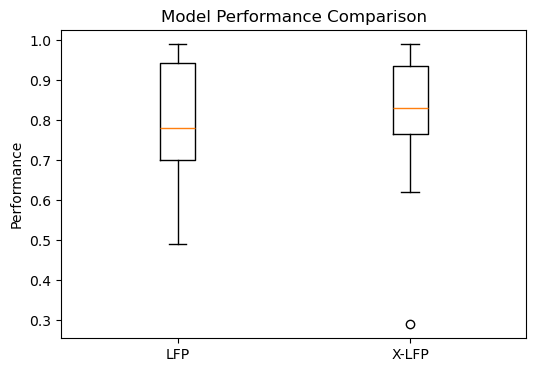

In [86]:
# box plots comparing model perfs from both groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([avg_perf_lfp, avg_perf_xlfp], labels=['LFP', 'X-LFP'])

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(avg_perf_lfp, avg_perf_xlfp)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))

if p<0.05:
    plt.text(1.2, 0.1, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

### Plot rate trajectories

Processing model type: xlfp, number of models: 18
PCA explained variance: [0.61195998 0.11487764 0.08087193], total: 0.8077095527772962
PCA explained variance: [0.52924159 0.16594309 0.12783976], total: 0.8230244311403729
PCA explained variance: [0.49430613 0.21125911 0.08107356], total: 0.7866388052697678
PCA explained variance: [0.49851911 0.21907776 0.11152136], total: 0.8291182232823754
PCA explained variance: [0.52325615 0.18100988 0.11038746], total: 0.8146534923886561
PCA explained variance: [0.50351151 0.19288667 0.09301683], total: 0.7894150013114566
PCA explained variance: [0.55787967 0.13269997 0.10272947], total: 0.7933091007478974
PCA explained variance: [0.41206887 0.28496915 0.09934915], total: 0.7963871732689186
PCA explained variance: [0.43216568 0.24481357 0.13134137], total: 0.8083206201717551
PCA explained variance: [0.49952813 0.2267078  0.11046443], total: 0.8367003599963599
PCA explained variance: [0.66073959 0.12552201 0.05946585], total: 0.8457274477447377
PCA 

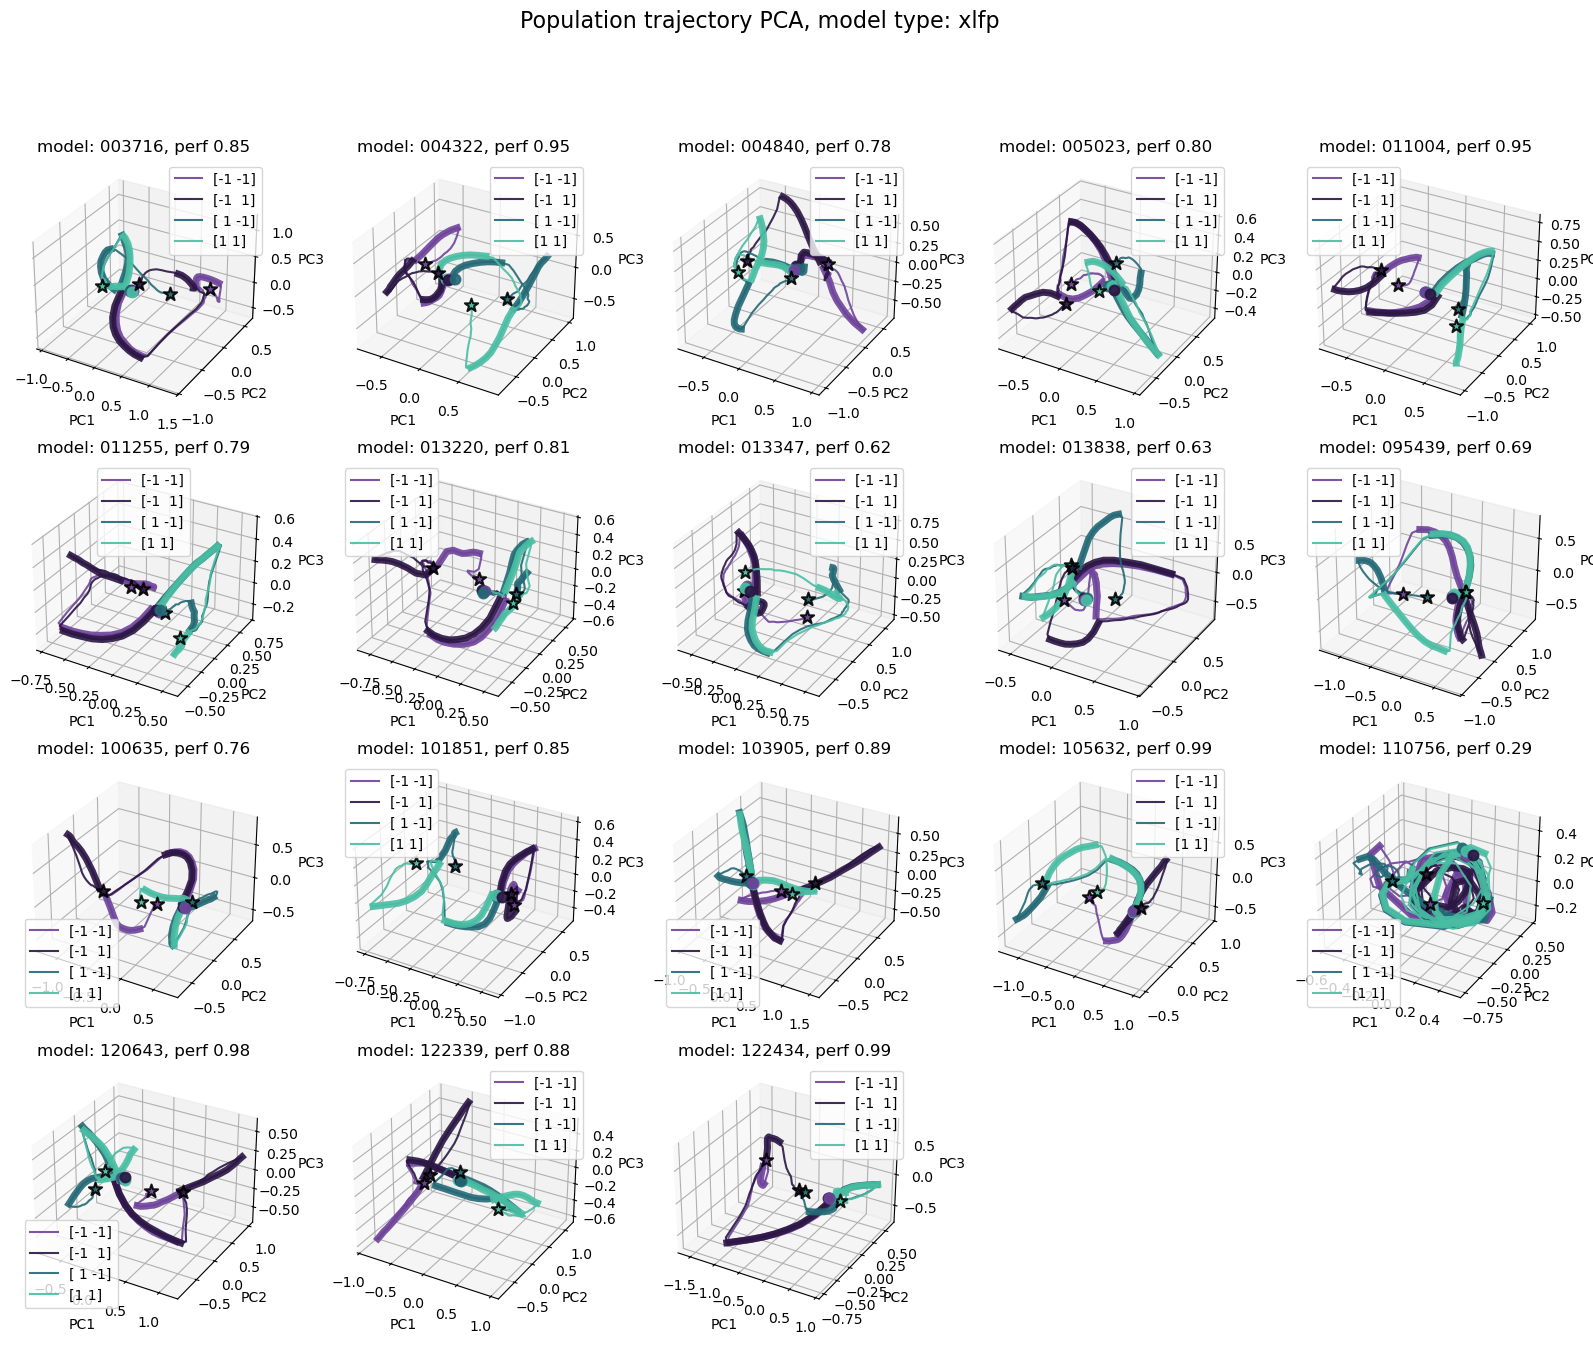

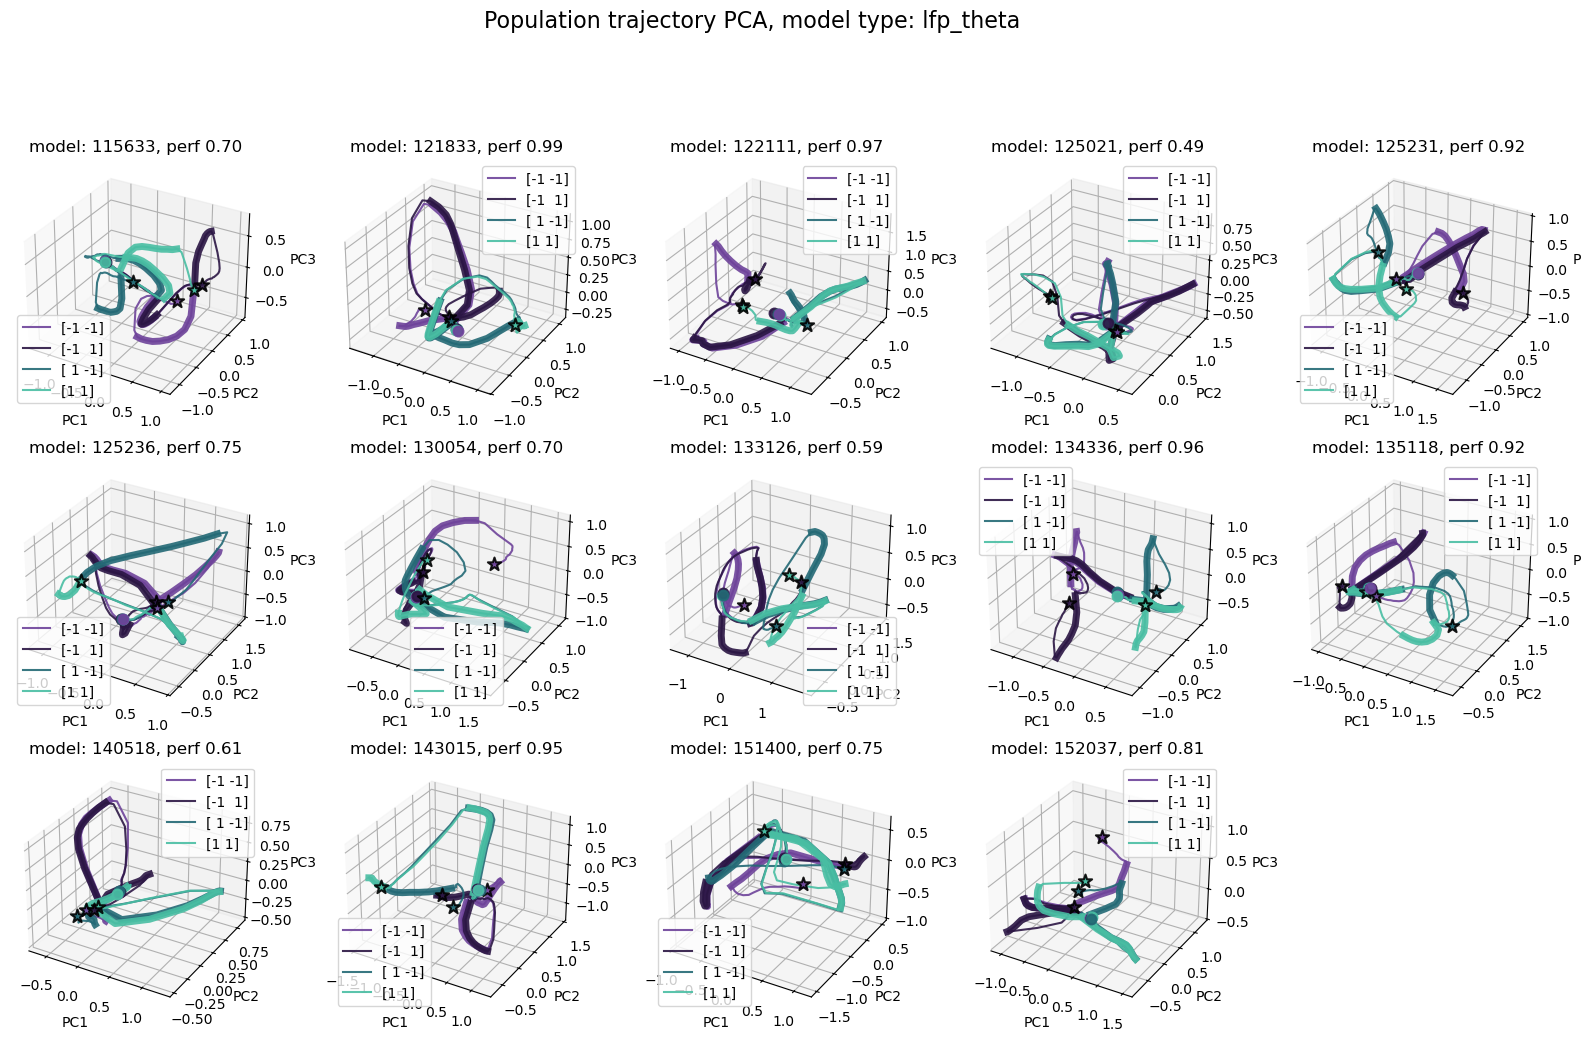

In [50]:
model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15))

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1, projection='3d')
        ax, _ = pu.plot_trajectory_pca(rates_data=neural_dict['r'], trial_labels=np.array(bhv_dict['trial_type']), 
                       settings=settings, cut_off=50, plot=1, ds=5, smooth=2, ax=ax,
                       title=f'model: {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    
    fig.suptitle(f'Population trajectory PCA, model type: {model_list_name}', fontsize=16)


Processing model type: xlfp, number of models: 18
PCA explained variance: [0.61287068 0.11172155 0.0803661 ], total: 0.8049583363355349
PCA explained variance: [0.5332351  0.16459129 0.12509185], total: 0.822918246169524
PCA explained variance: [0.49075282 0.2140708  0.08082418], total: 0.7856478012524822
PCA explained variance: [0.50622639 0.2090021  0.10978283], total: 0.8250113221467695
PCA explained variance: [0.52441318 0.18032352 0.10878652], total: 0.8135232197712405
PCA explained variance: [0.50864393 0.18529192 0.09234928], total: 0.7862851298029062
PCA explained variance: [0.57815535 0.11945819 0.09635011], total: 0.7939636560154212
PCA explained variance: [0.38479645 0.2581033  0.11365487], total: 0.7565546159242842
PCA explained variance: [0.41339528 0.25638514 0.12183988], total: 0.7916203019164769
PCA explained variance: [0.50144799 0.22089216 0.10969689], total: 0.8320370364593156
PCA explained variance: [0.657855   0.1237907  0.06084115], total: 0.8424868528576189
PCA e

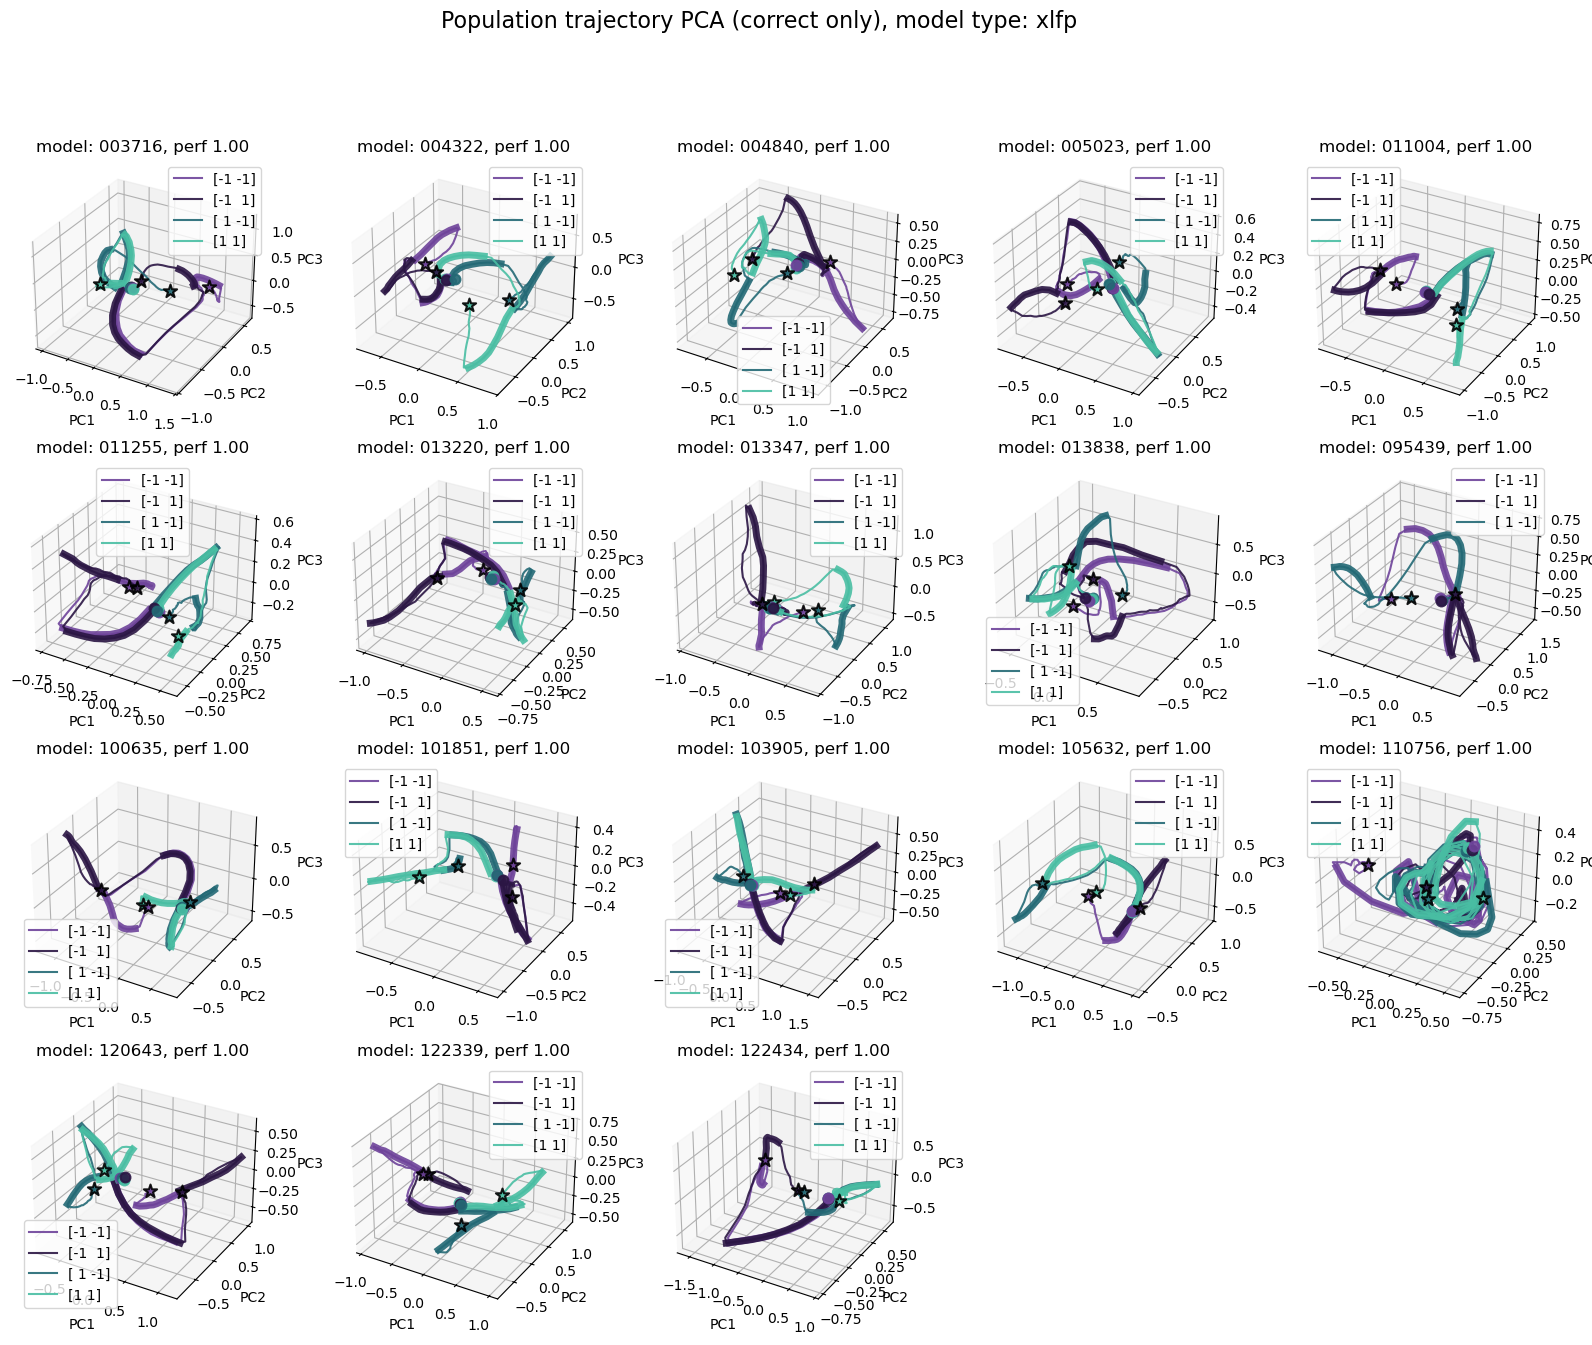

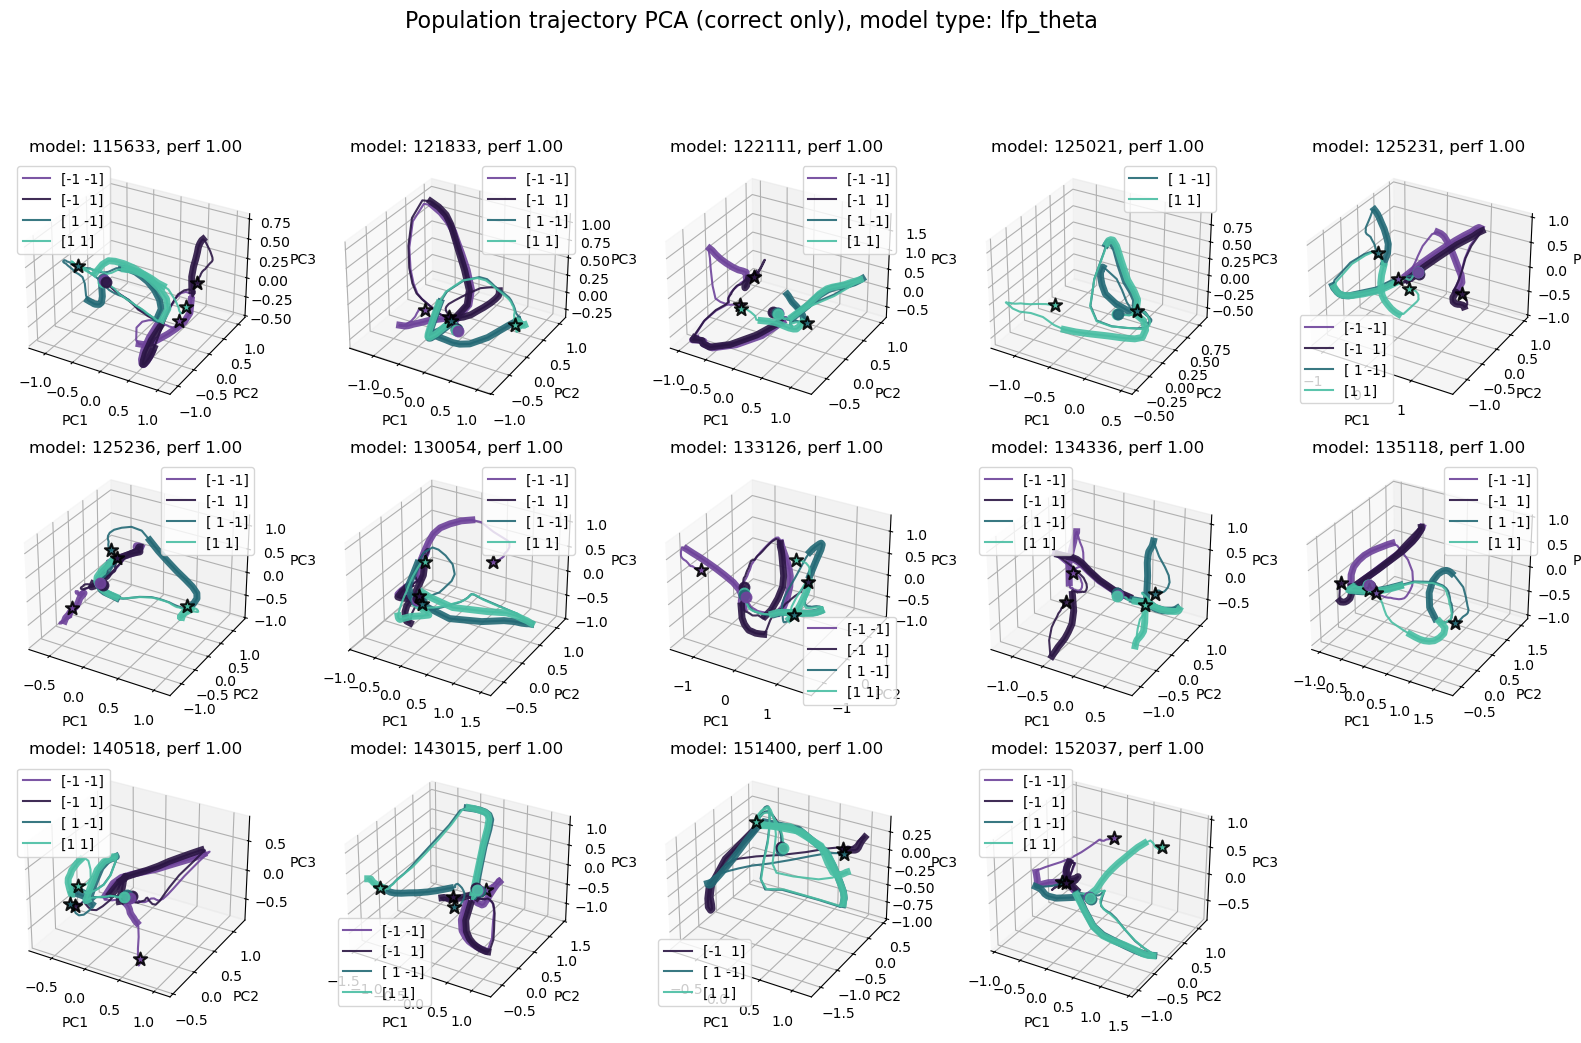

In [51]:
# trajectories for correct trials only

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15))

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        correct_trials = np.where(bhv_dict['perf'] == 1)[0]
        neural_dict['r'] = neural_dict['r'][correct_trials, :, :]
        bhv_dict['trial_type'] = np.array(bhv_dict['trial_type'])[correct_trials]
        bhv_dict['perf'] = np.array(bhv_dict['perf'])[correct_trials]
        
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1, projection='3d')
        ax, _ = pu.plot_trajectory_pca(rates_data=neural_dict['r'], trial_labels=np.array(bhv_dict['trial_type']), 
                       settings=settings, cut_off=50, plot=1, ds=5, smooth=2, ax=ax,
                       title=f'model: {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
    
    fig.suptitle(f'Population trajectory PCA (correct only), model type: {model_list_name}', fontsize=16)

### plot EPSP

In [54]:
neural_dict['epsp'].shape

(100, 500)

In [52]:
# spect calculation function in numpy

def compute_lfp_power_np(epsp, settings):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = settings['lfp_power_target']
    stim_on = settings['stim_on']

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]

    # --- baseline z-scoring ---
    start = 10
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


Processing model type: xlfp, number of models: 18
Processing model type: lfp_theta, number of models: 14


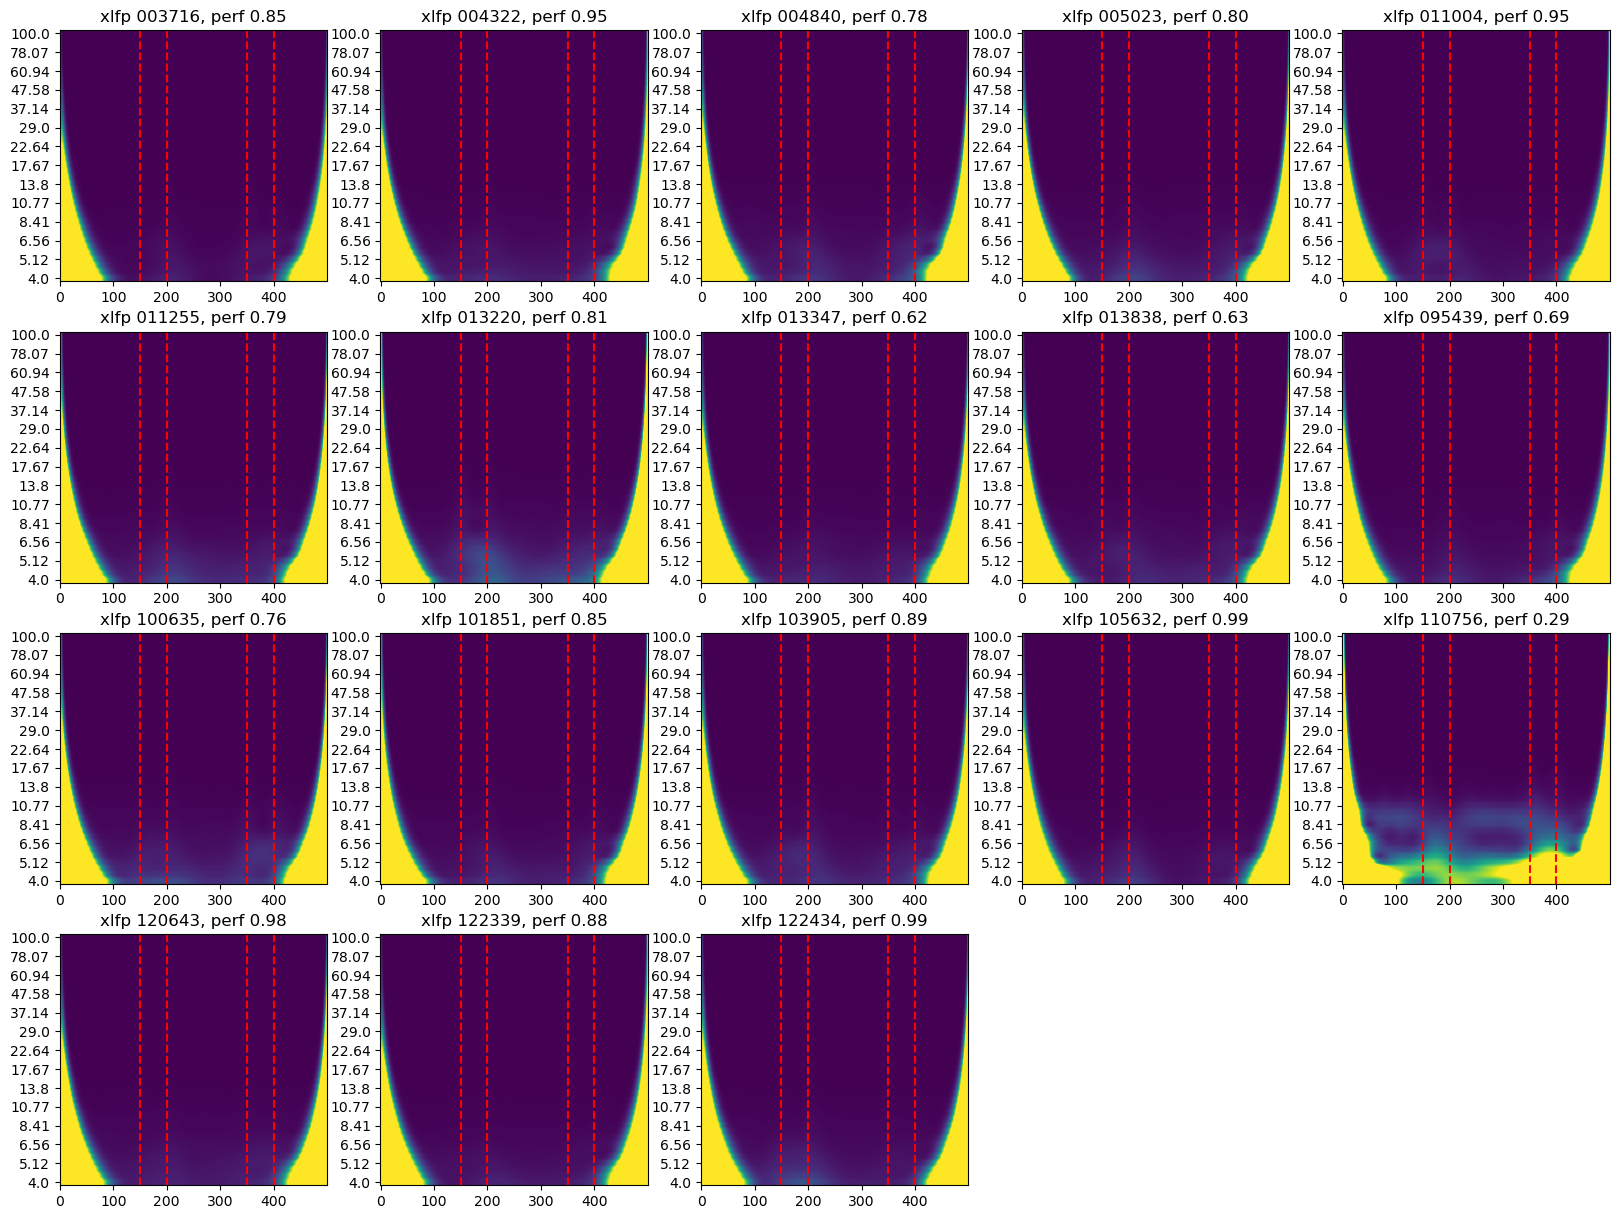

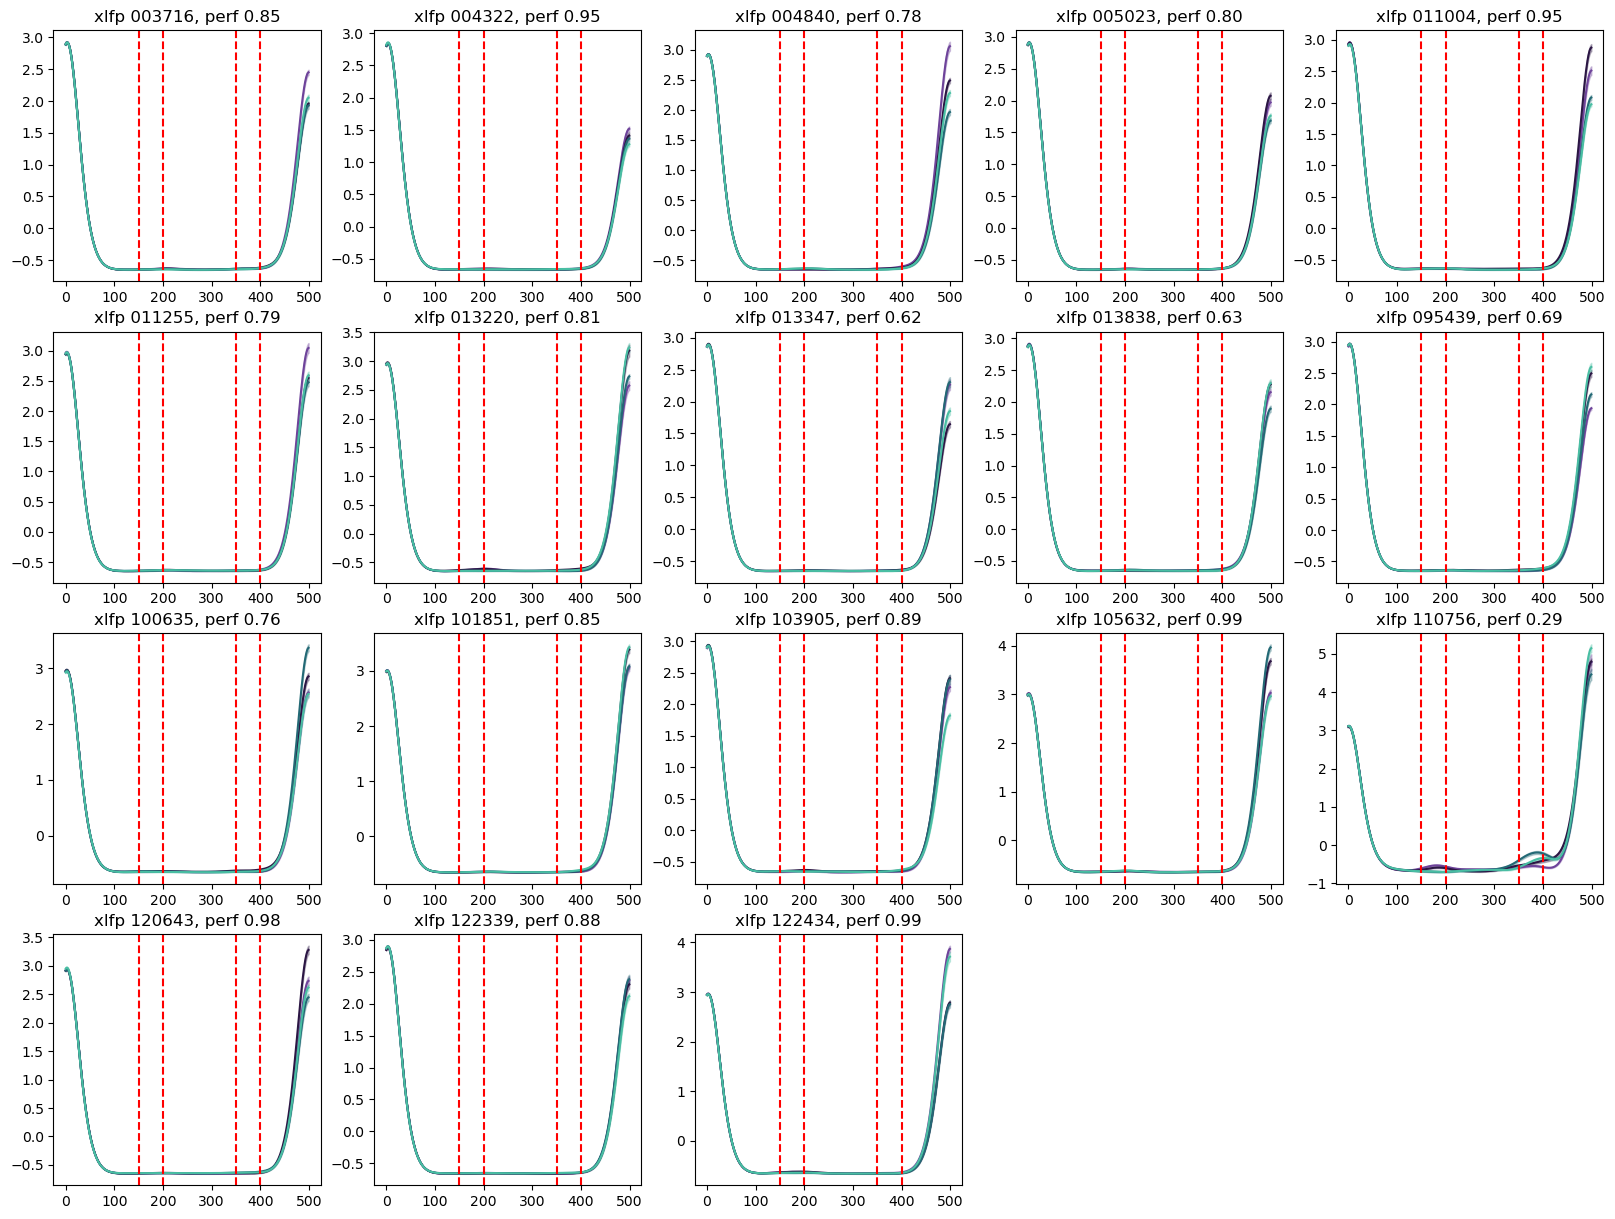

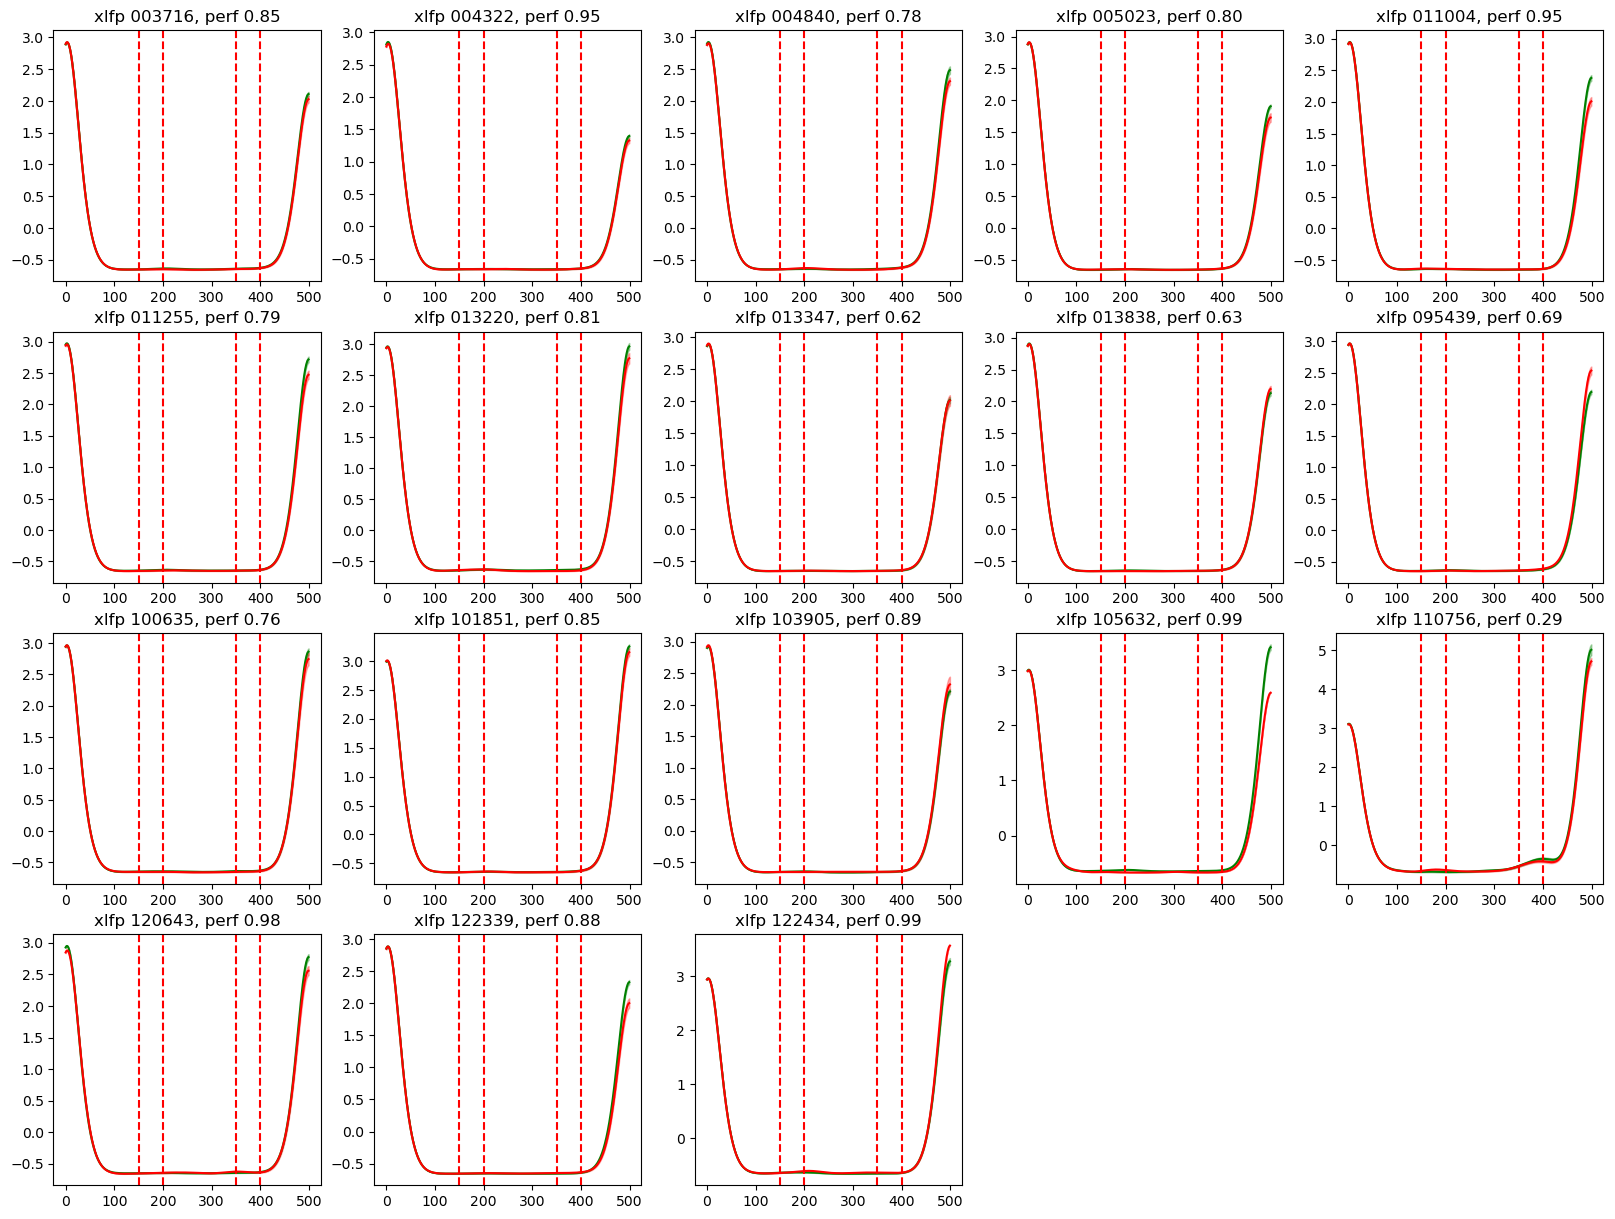

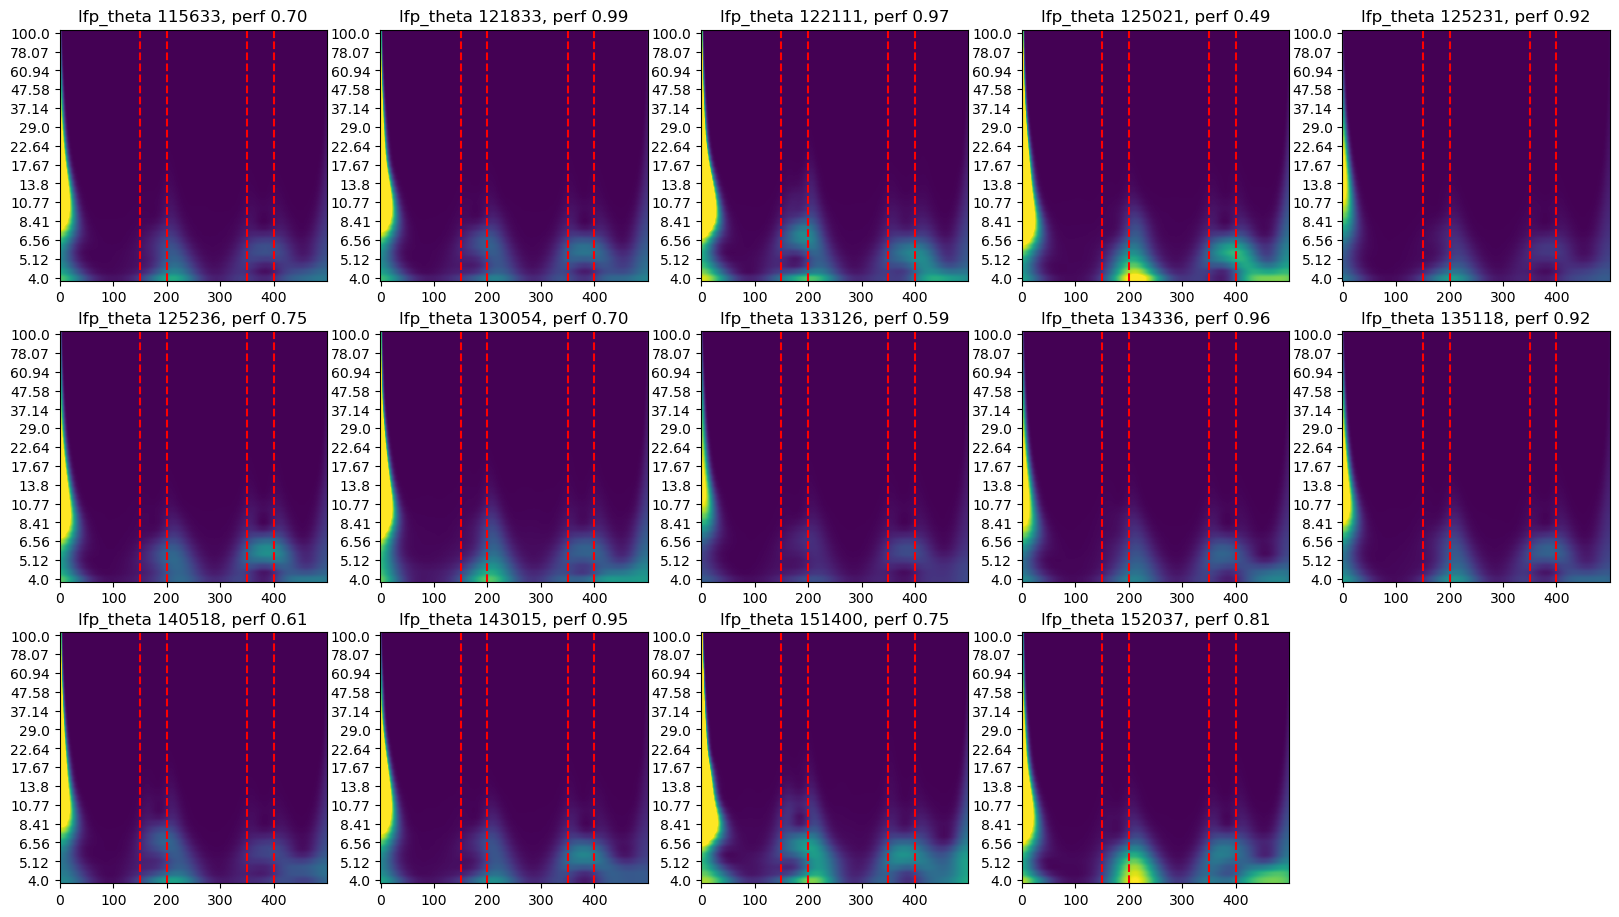

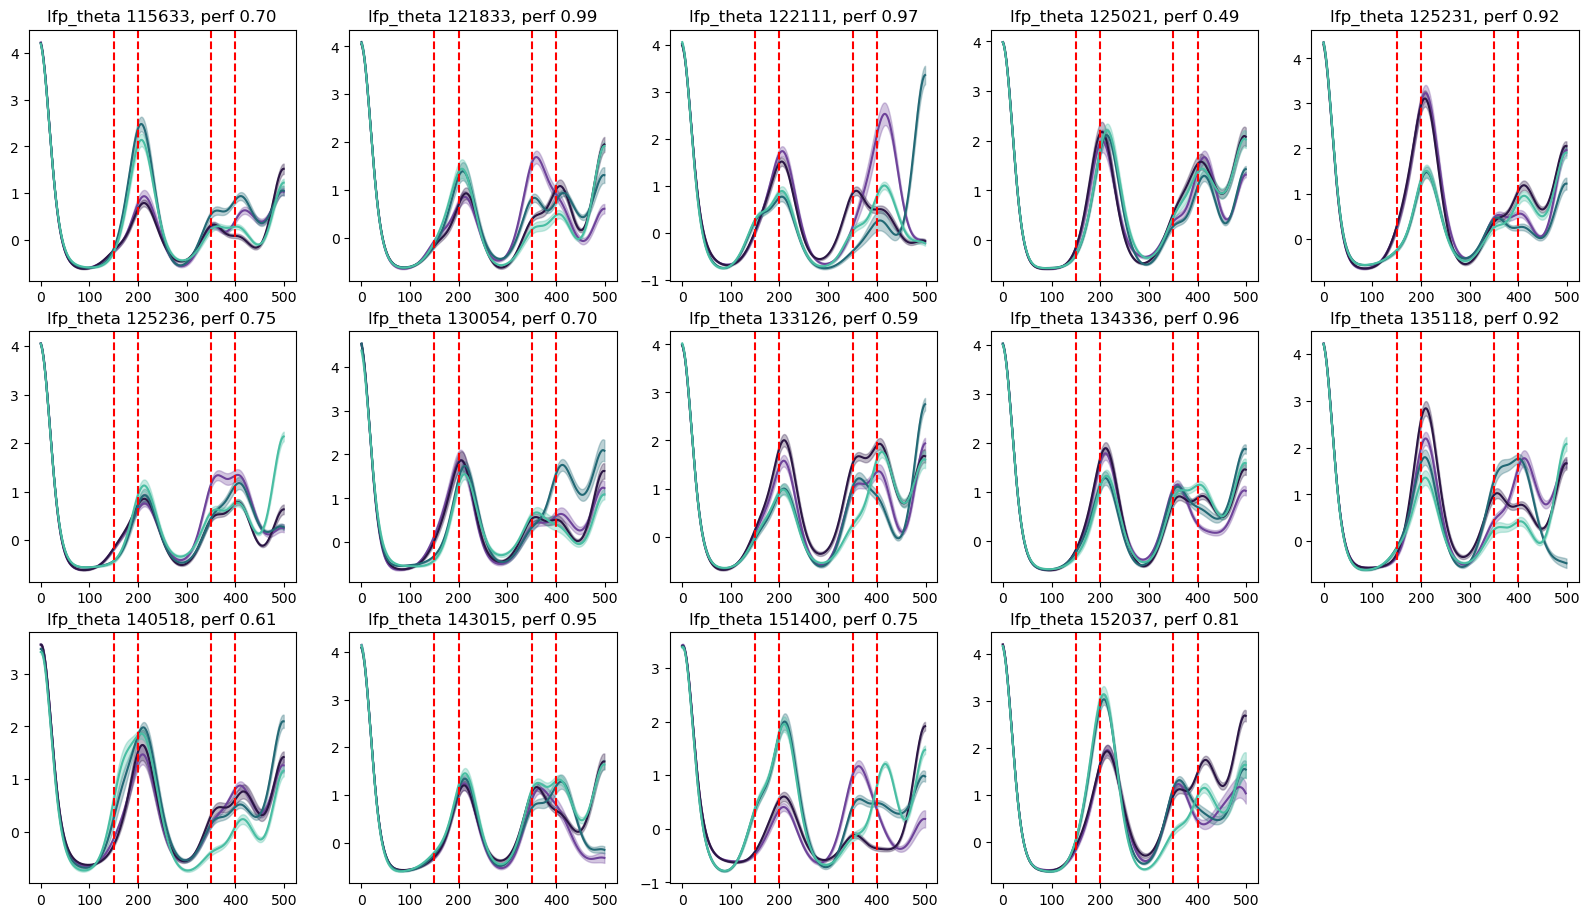

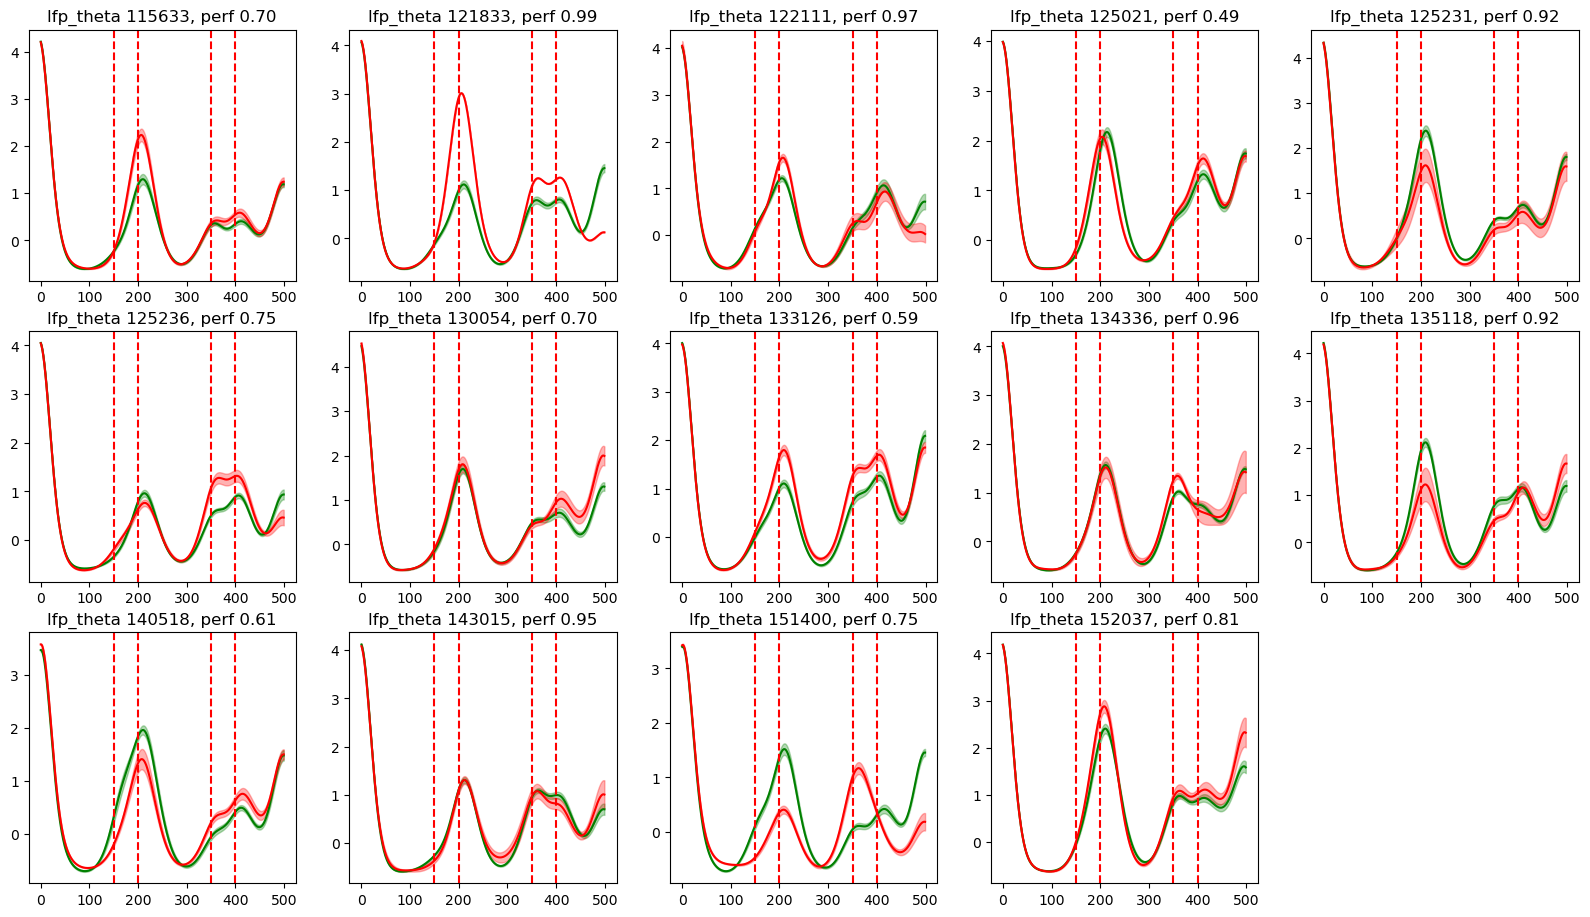

In [ ]:
# make plots: spect, bandpower by trial type, bandpower by correct/incorrect

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig1 = plt.figure(figsize=(20, 15)) # spectrogram
    fig2 = plt.figure(figsize=(20, 15)) # band power, split by trial type
    fig3 = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
            avg_power += trial_power / n_trials
            
        # first plot spectrogram
        ax1 = fig1.add_subplot(4, 5, model_list.index(model_name)+1)
        ax1.imshow(avg_power.T, aspect='auto', origin='lower',
               vmin=0, vmax=1.2)
        ax1.set_yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
        # ax1.colorbar(label='Power')
        ax1.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax1.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax1.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
        
        # then plot band power, split by trial type
        ax2 = fig2.add_subplot(4, 5, model_list.index(model_name)+1)
        stims, colors = ld.get_trialtype_colors()
        trial_types, trial_idxs = np.unique(np.array(bhv_dict['trial_type']), axis=0, return_inverse=True)
        for i, trial_type in enumerate(trial_types):
            trials_idx = (trial_idxs == i)
            powerband_mean = np.mean(trial_powerband[trials_idx, :], axis=0)
            powerband_sem = np.std(trial_powerband[trials_idx, :], axis=0) / np.sqrt(np.sum(trials_idx))
            ax2.plot(powerband_mean, color=colors[i])#, label=stims[i])
            ax2.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color=colors[i], alpha=0.3)
        ax2.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax2.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax2.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
        
        # finally plot band power, split by correct/incorrect
        ax3 = fig3.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        powerband_mean = np.mean(trial_powerband[correct_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[correct_trials, :], axis=0) / np.sqrt(np.sum(correct_trials))
        ax3.plot(powerband_mean, color='g', label='correct')
        ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax3.plot(powerband_mean, color='r', label='incorrect')
        ax3.fill_between(np.arange(settings['T']), powerband_mean - powerband_sem, powerband_mean + powerband_sem, color='r', alpha=0.3)
        ax3.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax3.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax3.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: xlfp, number of models: 18
Processing model type: lfp_theta, number of models: 14


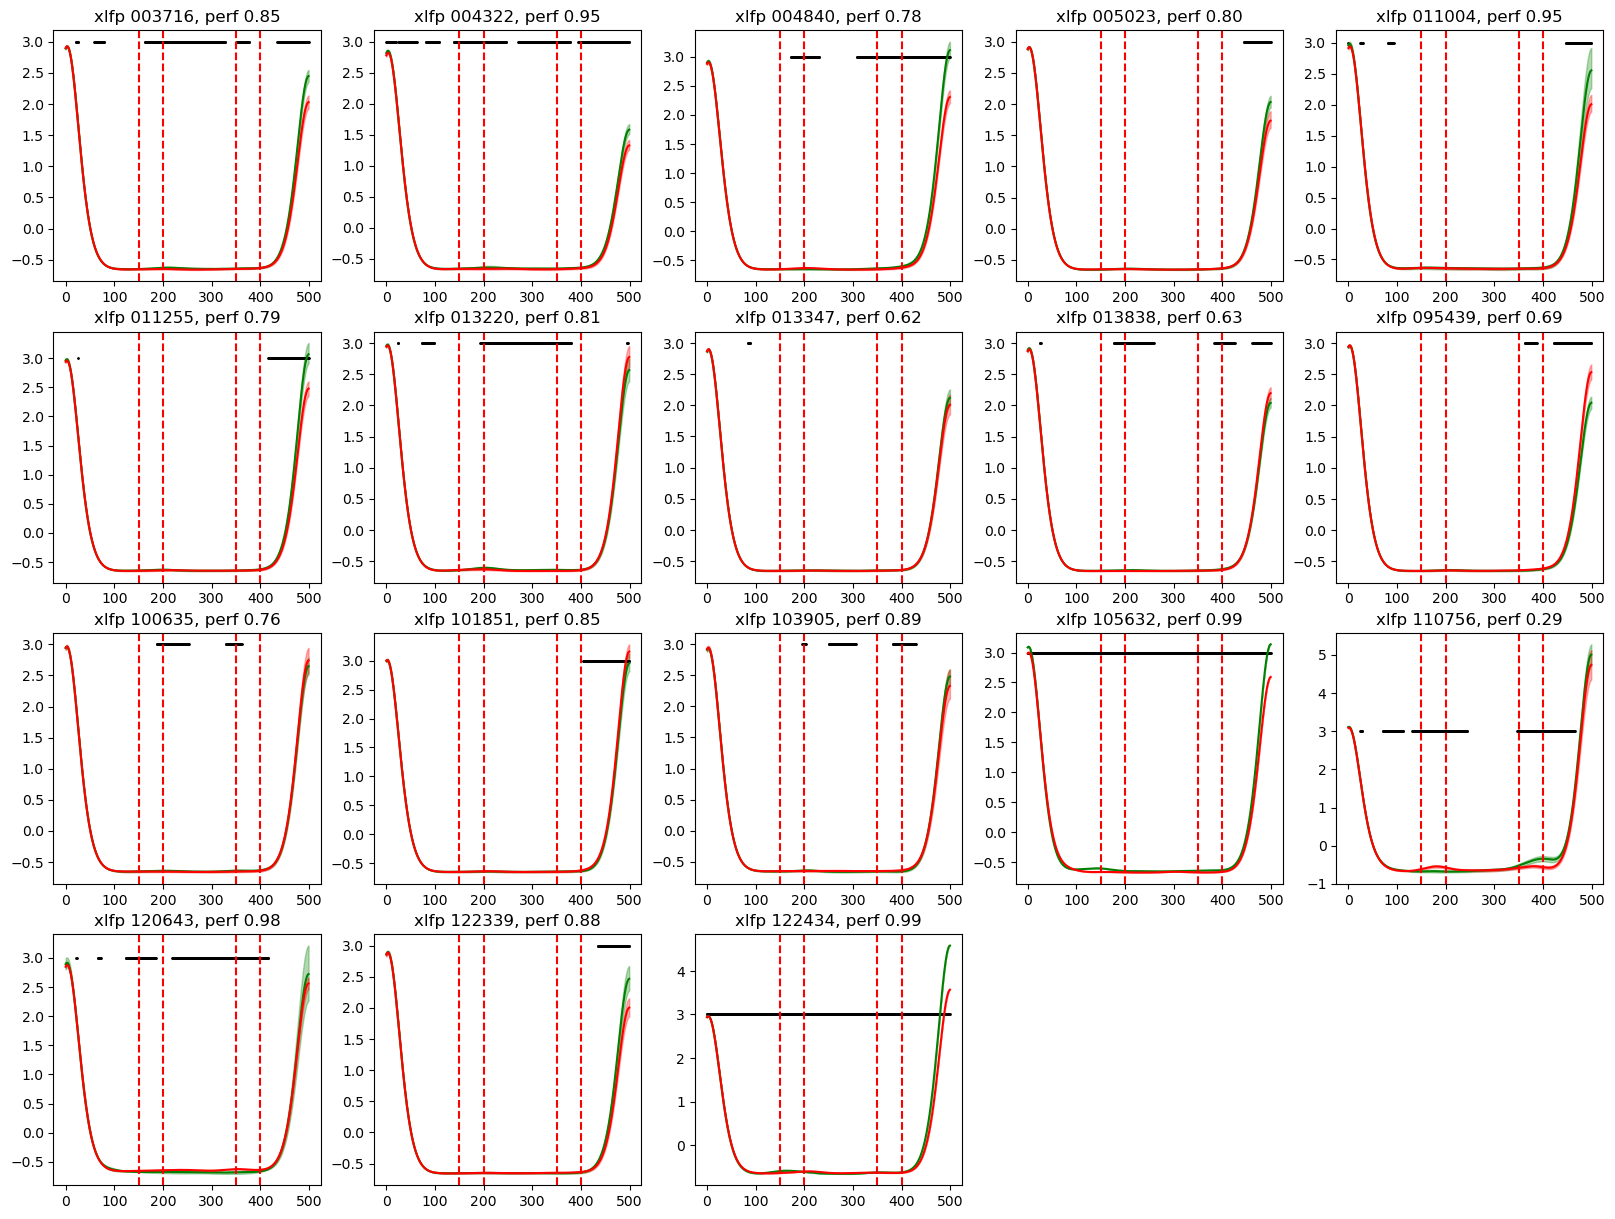

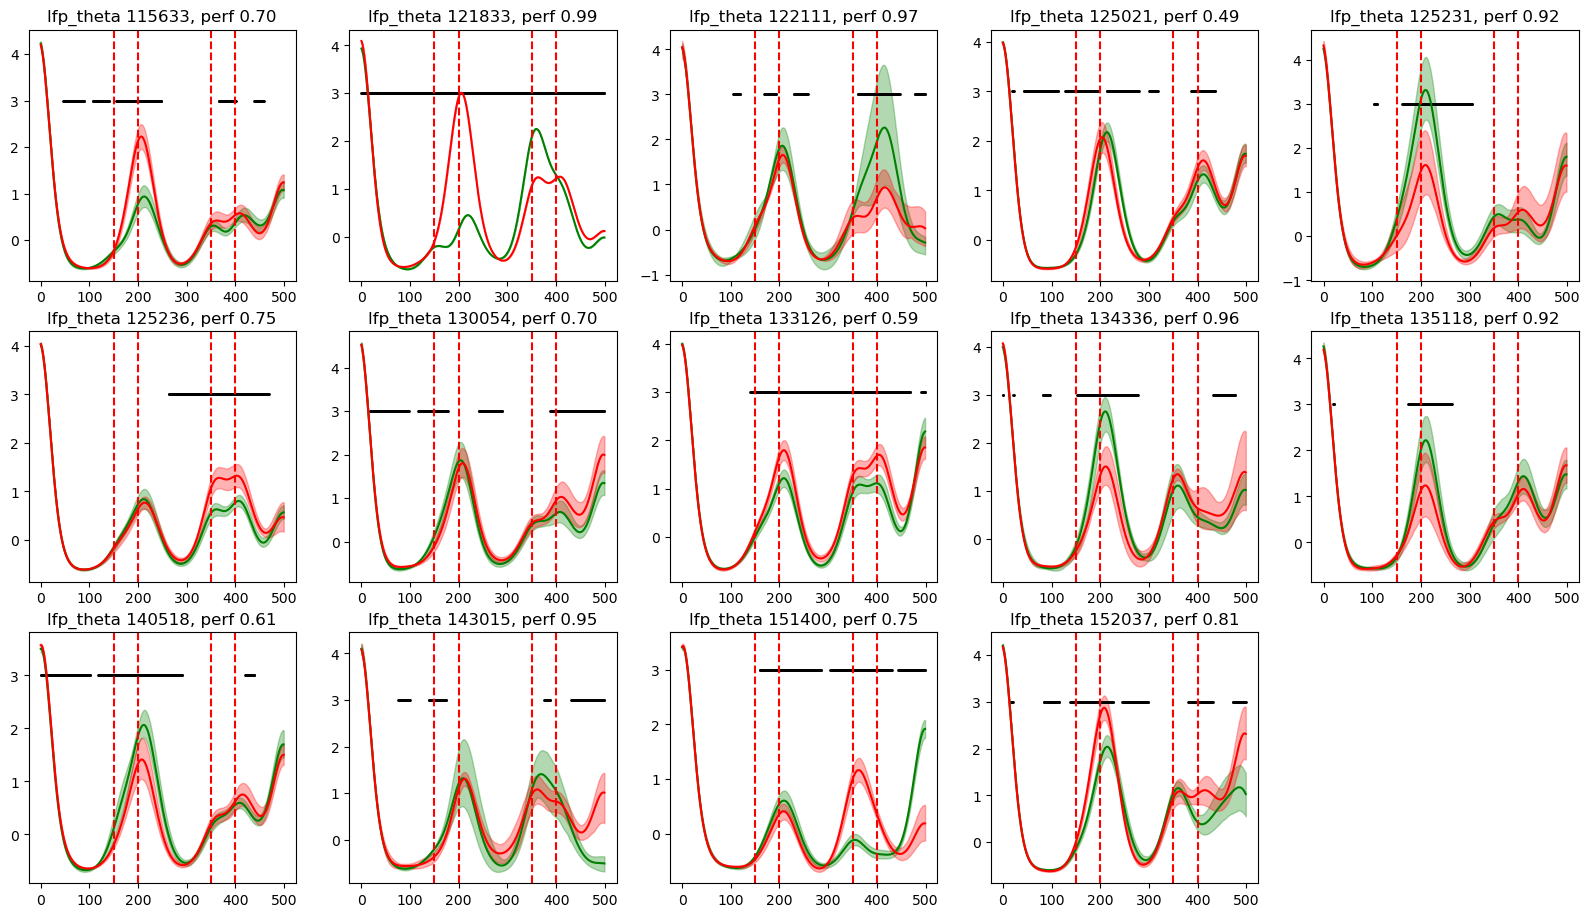

In [93]:
# make plot: bandpower by correct/incorrect w bootstrapping

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
            avg_power += trial_power / n_trials
            
        # finally plot band power, split by correct/incorrect
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        
        t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                               trial_powerband[incorrect_trials, :], 
                                                                                               nboot, CI_int, n_jobs=-1, random_seed=None)
        
        ax.plot(t1_avg.mean(axis=1), color='g', label='correct')
        ax.fill_between(np.arange(settings['T']), t1_CI[:,0], t1_CI[:,1], color='g', alpha=0.3)
        powerband_mean = np.mean(trial_powerband[incorrect_trials, :], axis=0)
        powerband_sem = np.std(trial_powerband[incorrect_trials, :], axis=0) / np.sqrt(np.sum(incorrect_trials))
        ax.plot(t2_avg.mean(axis=1), color='r', label='incorrect')
        ax.fill_between(np.arange(settings['T']), t2_CI[:,0], t2_CI[:,1], color='r', alpha=0.3)
        # plot bar for significant difference
        sig_idx = np.where(p_diff < 0.05)[0]
        ax.scatter(sig_idx, np.ones_like(sig_idx)*3, color='k', s=1)
        ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')



Processing model type: xlfp, number of models: 18


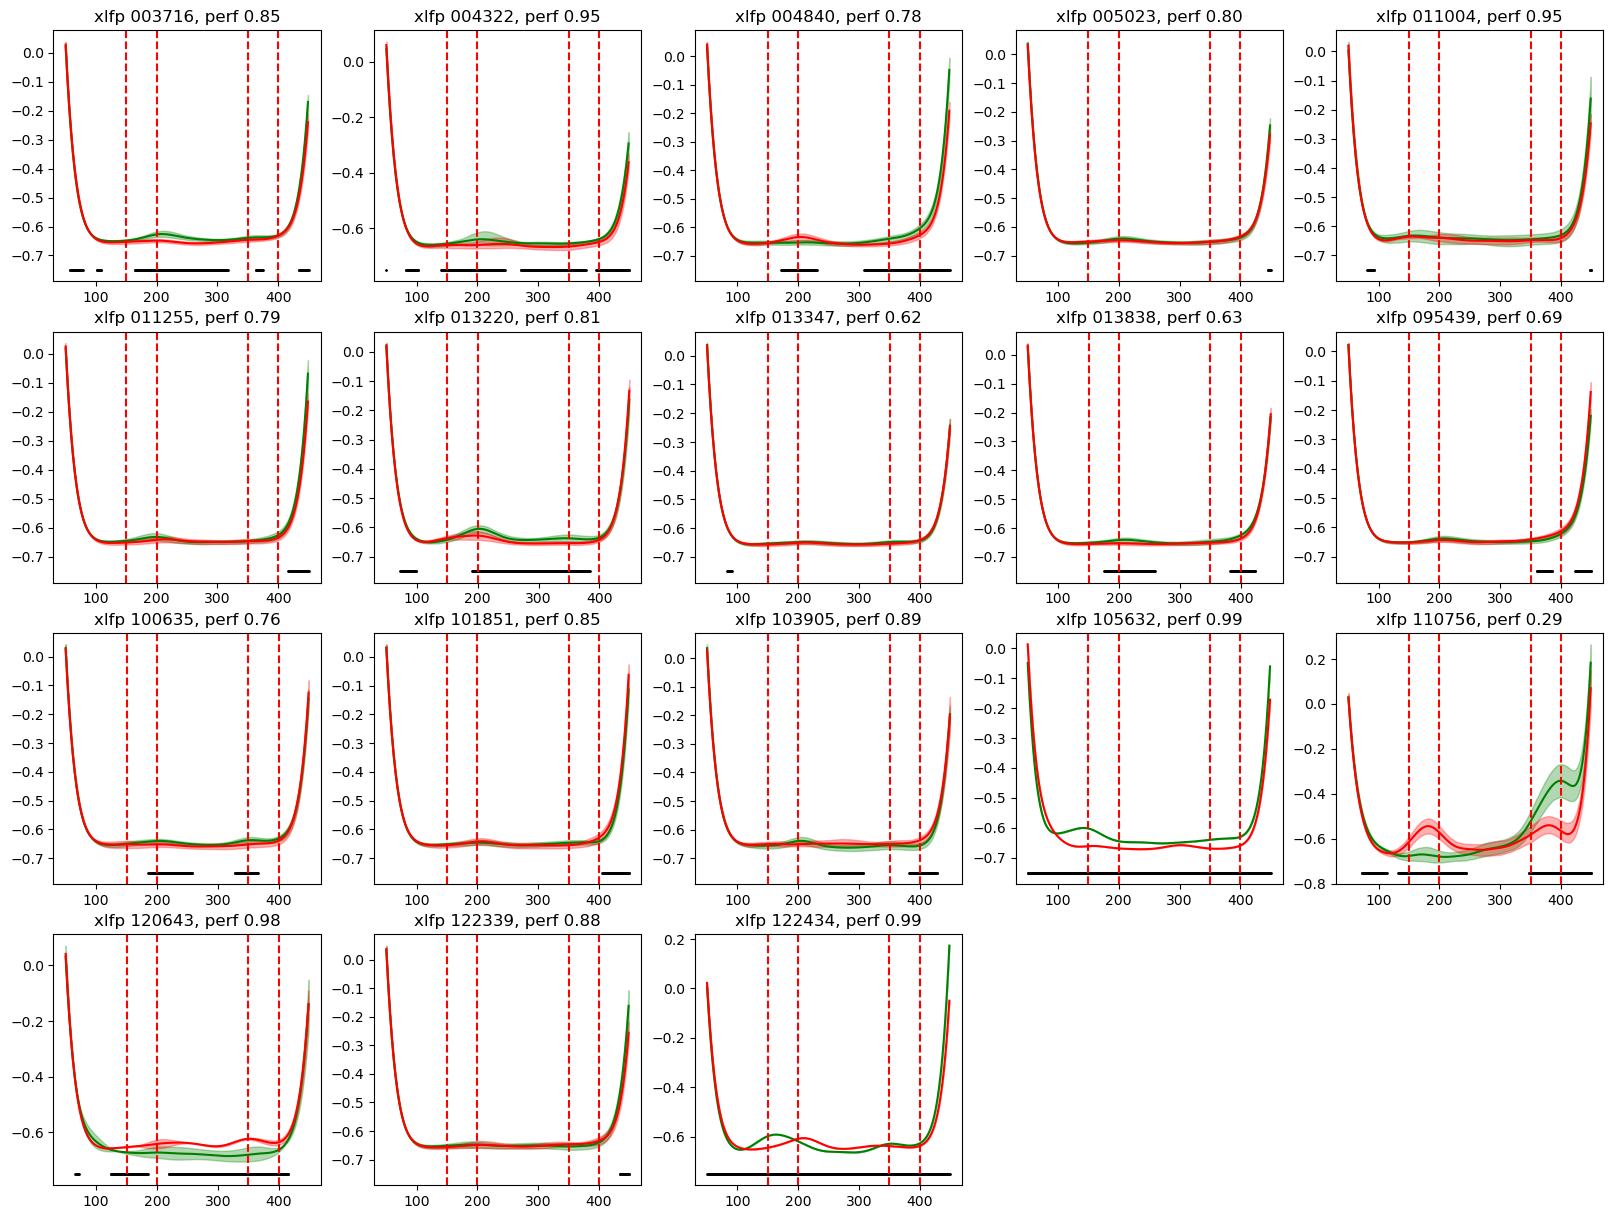

Processing model type: lfp_theta, number of models: 14


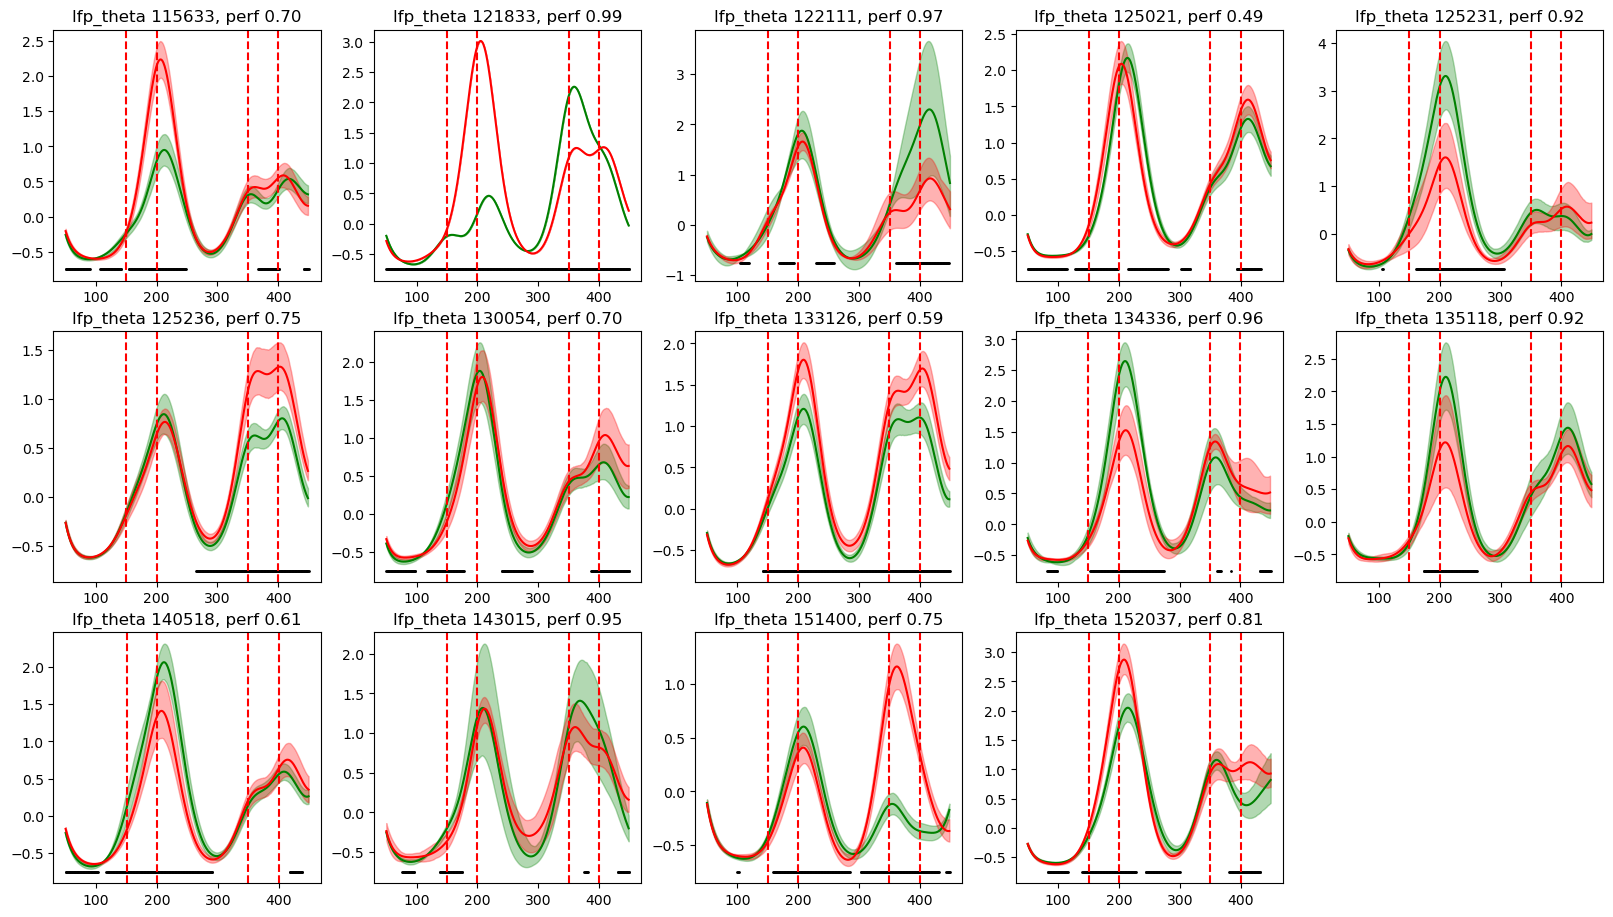

In [95]:
# make plot: bandpower by correct/incorrect w bootstrapping (cutting x-axis)

from bootstrap_method import fnc_time_bootstrap_optimized_retX

random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)

model_lists = [xlfp_model_list, lfp_theta_model_list] #, lfp_alpha_model_list]
model_dirs = [xlfp_model_dir, lfp_model_dir] #, lfp_model_dir]
model_list_names = ['xlfp', 'lfp_theta'] #, 'lfp_alpha']

for model_lists, model_dirs, model_list_names in zip(model_lists, model_dirs, model_list_names):
    model_list = model_lists
    model_dir = model_dirs
    model_list_name = model_list_names

    print(f'Processing model type: {model_list_name}, number of models: {len(model_list)}')
    
    # create figure
    fig = plt.figure(figsize=(20, 15)) # band power, split by correct/incorrect

    for model_name in model_list:
        # print(f"\nModel: {model_name}")
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        
        # get neural and behavioral data
        neural_dict = pk.load(open(os.path.join(output_dir, 'neural_dict.pkl'), 'rb'))
        bhv_dict = pk.load(open(os.path.join(output_dir, 'bhv_dict.pkl'), 'rb'))
        
        # calculate spectrogram data for all trials
        n_freqs = 40
        n_trials = neural_dict['epsp'].shape[0]

        trial_powerband = np.zeros((n_trials, settings['T'])) # [N, T]
        avg_power = np.zeros((settings['T'], n_freqs)) # [T, F]
        for i in range(n_trials):
            trial_power, freqs, trial_powerband[i, :] = compute_lfp_power_np(neural_dict['epsp'][i, :], settings)
            avg_power += trial_power / n_trials
            
        # finally plot band power, split by correct/incorrect
        ax = fig.add_subplot(4, 5, model_list.index(model_name)+1)
        correct_trials = (np.array(bhv_dict['perf']) == 1)
        incorrect_trials = (np.array(bhv_dict['perf']) == 0)
        
        t1_avg, t1_CI, t2_avg, t2_CI, diff_avg, diff_CI, p_diff = fnc_time_bootstrap_optimized_retX(trial_powerband[correct_trials, :], 
                                                                                               trial_powerband[incorrect_trials, :], 
                                                                                               nboot, CI_int, n_jobs=-1, random_seed=None)
        plot_x = np.arange(50, 450)
        ax.plot(plot_x, t1_avg.mean(axis=1)[plot_x], color='g', label='correct')
        ax.fill_between(plot_x, t1_CI[plot_x,0], t1_CI[plot_x,1], color='g', alpha=0.3)
        ax.plot(plot_x, t2_avg.mean(axis=1)[plot_x], color='r', label='incorrect')
        ax.fill_between(plot_x, t2_CI[plot_x,0], t2_CI[plot_x,1], color='r', alpha=0.3)
        # plot bar for significant difference
        sig_idx = np.where(p_diff < 0.05)[0]
        sig_idx = sig_idx[(sig_idx>=50) & (sig_idx<=450)]
        ax.scatter(sig_idx, np.ones_like(sig_idx)*-0.75, color='k', s=1)
        ax.set_title(f'{model_list_name} {model_name[-10:-4]}, perf {(np.mean(bhv_dict["perf"])):.2f}')
        ax.axvline(x=settings['stim_on'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay'], color='r', linestyle='--')
        ax.axvline(x=settings['stim_on']+settings['stim_dur']+settings['delay']+settings['stim_dur'], color='r', linestyle='--')
    
    plt.show()



### extend maintenance

#### 50 to 150

In [6]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 150, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [7]:
u, label = generate_input_stim_xor(settings)
trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]
x, r, o, epsp = model.eval_tf(model_dir=f'{lfp_model_dir}/{lfp_model_list[0]}', settings=settings, u=u)
print(u.shape, label, trial_type)
print(x.shape, r.shape, o.shape, epsp.shape)

(2, 500) same [-1. -1.]
(200, 500) (200, 500) (500,) (500,)


In [30]:
# model eval on 100 random trials

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
eval_perf = np.zeros(n_trials)
eval_os = np.zeros((n_trials, settings['T']))

for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_xor(settings)
    _, _, eval_o, _ = model.eval_tf(model_dir=f'{lfp_model_dir}/{lfp_model_list[0]}', settings=settings, u=eval_u)
    eval_os[i, :] = np.squeeze(eval_o)
    if eval_label == 'same':
        if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
            eval_perf[i] = 1
    else:
        if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
            eval_perf[i] = 1

eval_perf_mean = np.nanmean(eval_perf)
print("Performance: %.2f"%(eval_perf_mean))

Performance: 0.76


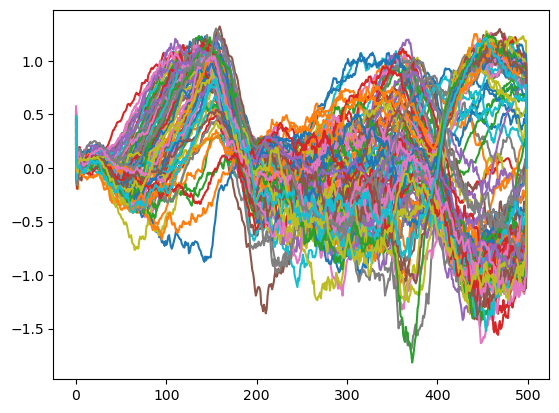

In [31]:
plt.figure()
plt.plot(eval_os.T)
plt.show()

### some connectivity stuff

In [44]:
all_models_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'

In [49]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import connectivity_utils as cu

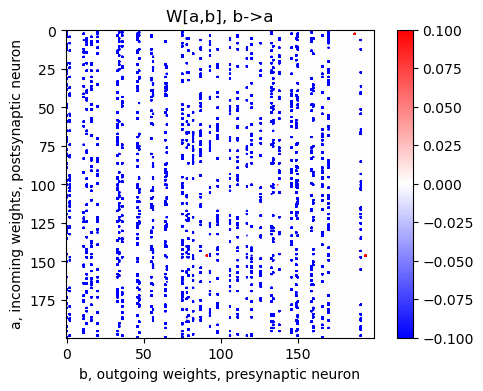

In [52]:
w = model_data['w']
m = model_data['m']
final_w = np.matmul(w, m)
cu.plot_connectivity_matrix(final_w)

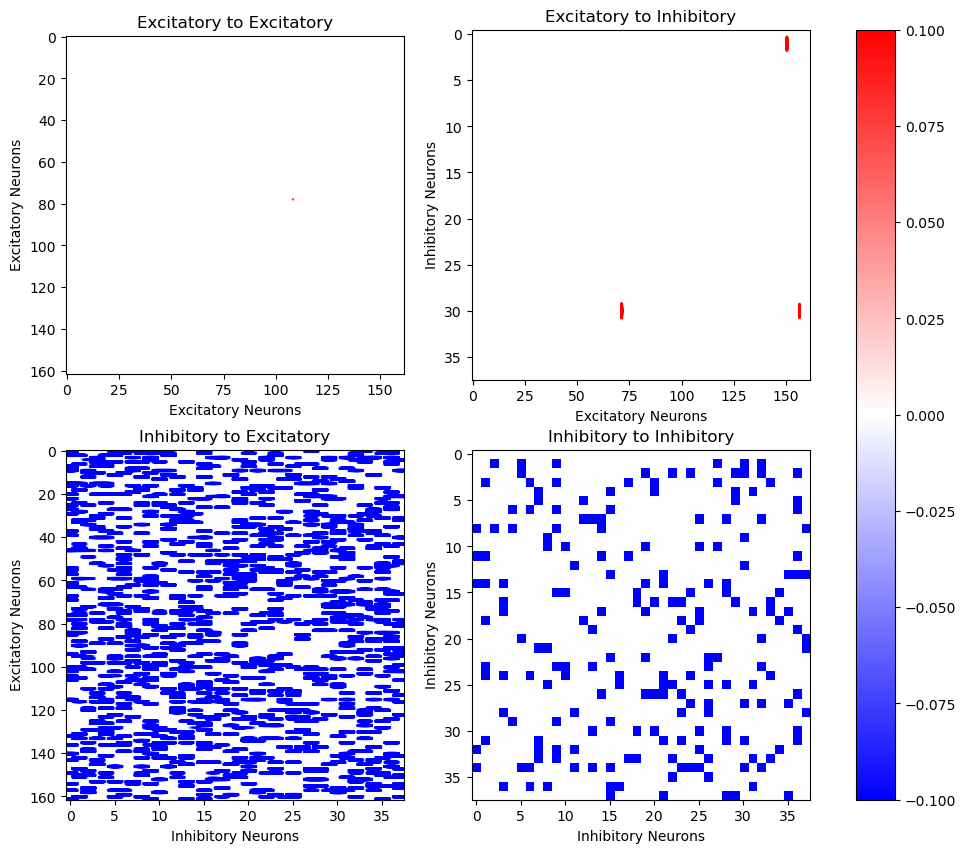

In [53]:
cu.plot_connectivity_matrix_by_type(final_w, exc_ind, inh_ind)

In [54]:
def get_num_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ii != 0), np.sum(ee != 0), np.sum(ei != 0), np.sum(ie != 0), 

def get_proportion_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ee != 0) / ee.size, np.sum(ii != 0) / ii.size, np.sum(ei != 0) / ei.size, np.sum(ie != 0) / ie.size

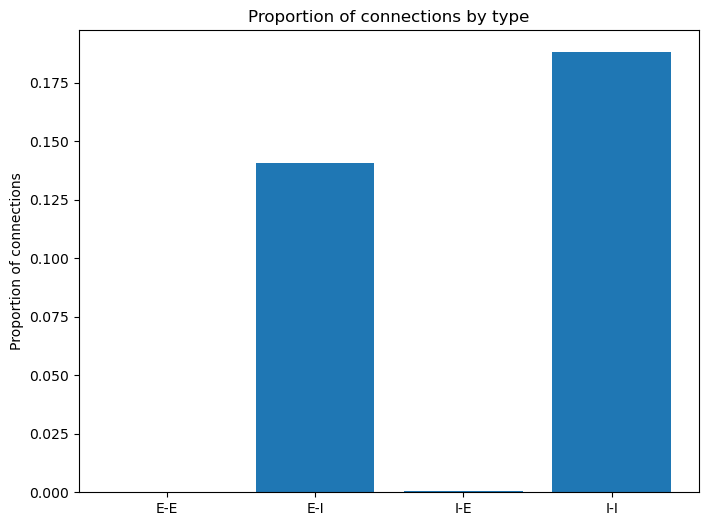

In [55]:
connect_props = get_proportion_connections(final_w, exc_ind, inh_ind)

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'E-I', 'I-E', 'I-I'], connect_props)
plt.ylabel('Proportion of connections')
plt.title('Proportion of connections by type')
plt.show()

In [ ]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import FR_RNN_dale


In [58]:
# plot comparing trained and untrained

trained_num = []
untrained_num = []
trained_prop = []
untrained_prop = []

for model_num in range(len(model_list)):
    
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    
    # trained
    w = model_data['w']
    m = model_data['m']
    W = np.matmul(w, m)
    
    exc = model_data['exc']
    exc_ind = np.where(exc == 1)[0]
    inh = model_data['inh']
    inh_ind = np.where(inh == 1)[0]
    
    
    trained_num.append(get_num_connections(W, exc_ind, inh_ind))
    trained_prop.append(get_proportion_connections(W, exc_ind, inh_ind))

    # untrained
    N = 200
    net = FR_RNN_dale(N, .2, .2, np.float32(np.random.randn(N, 2)), 0, 'gaus', 1.5, True, np.float32(np.random.randn(1, N)/100))
    W_init = net.W @ net.mask
    exc_ind_init = np.where(net.exc == 1)[0]
    inh_ind_init = np.where(net.exc == 0)[0]

    untrained_num.append(get_num_connections(W_init, exc_ind_init, inh_ind_init))
    untrained_prop.append(get_proportion_connections(W_init, exc_ind_init, inh_ind_init))
# convert to numpy arrays
trained_num = np.array(trained_num)
untrained_num = np.array(untrained_num)
trained_prop = np.array(trained_prop)
untrained_prop = np.array(untrained_prop)

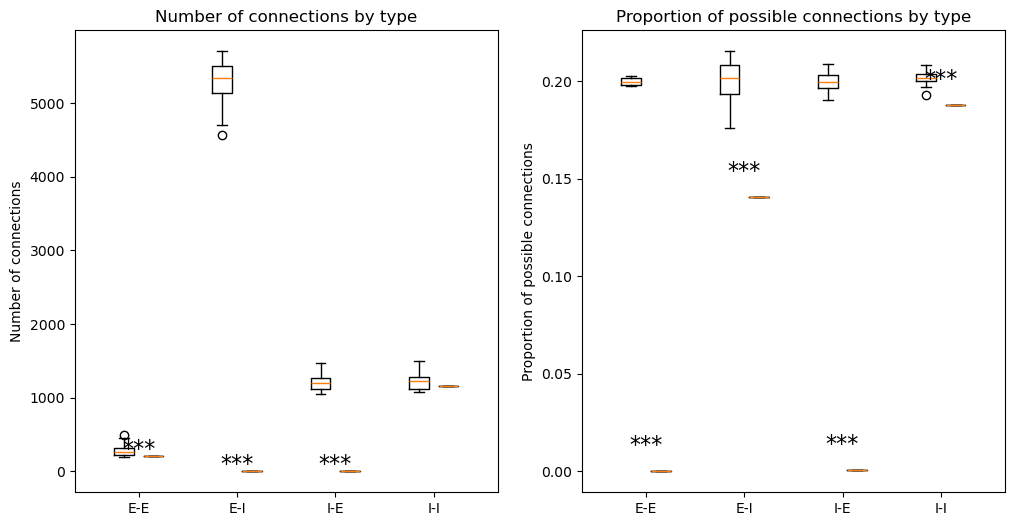

In [59]:
# plot trained vs untrained number of connections

connection_types = ['E-E', 'E-I', 'I-E', 'I-I']
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].boxplot(untrained_num, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[0].boxplot(trained_num, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[0].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[0].set_ylabel('Number of connections')
axs[0].set_title('Number of connections by type')
# axs[0].legend()

axs[1].boxplot(untrained_prop, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[1].boxplot(trained_prop, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[1].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[1].set_ylabel('Proportion of possible connections')
axs[1].set_title('Proportion of possible connections by type')
# axs[1].legend() 

# plot mann whitney U test results for num and proportion of connections
from scipy.stats import mannwhitneyu
p_values_num = []
p_values_prop = []
# for number of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_num[:, i], untrained_num[:, i])
    p_values_num.append(p)
p_values_num = np.array(p_values_num)

# for proportion of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_prop[:, i], untrained_prop[:, i])
    p_values_prop.append(p)
p_values_prop = np.array(p_values_prop)

# plot p-values as stars on top of the boxplots
for i, p in enumerate(p_values_num):
    if p < 0.001:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '*', fontsize=16, ha='center')
    
for i, p in enumerate(p_values_prop):
    if p < 0.001:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '*', fontsize=16, ha='center')

# plt.tight_layout()

plt.show()

### neural outputs from spiking model

In [14]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import single_neuron_utils as sn

In [20]:
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'

model_name = model_fname[:-4]
model_dir = os.path.join(all_models_dir, model_name)
delay=50

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
data_files

['/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/neuraldata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/timingdata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/bhvdata_raw_delay50.mat']

In [21]:
# neural data
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True,
                                                  all_models_dir = all_models_dir)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)
times_ms, _,_ = ld.get_times_dict('ds', 'delay', 50, model_name,
                                  all_models_dir=all_models_dir)

In [22]:
print(f'Average performance for delay {delay}: {trial_perfs.mean()}')

Average performance for delay 50: 0.511


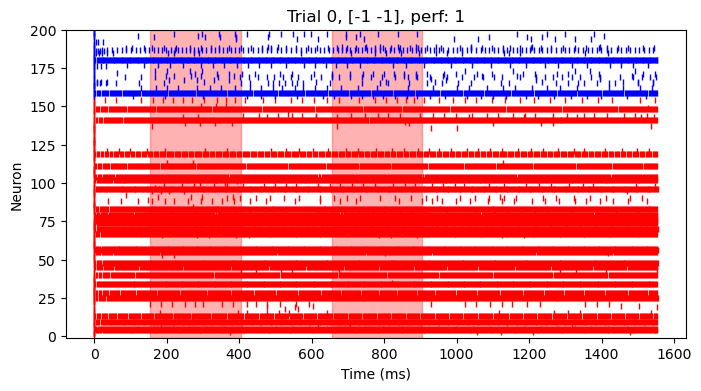

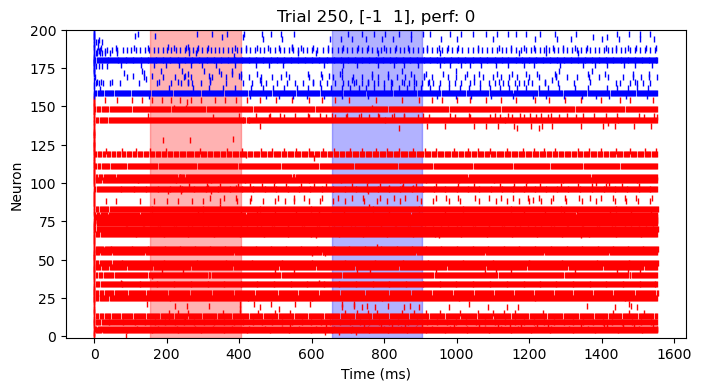

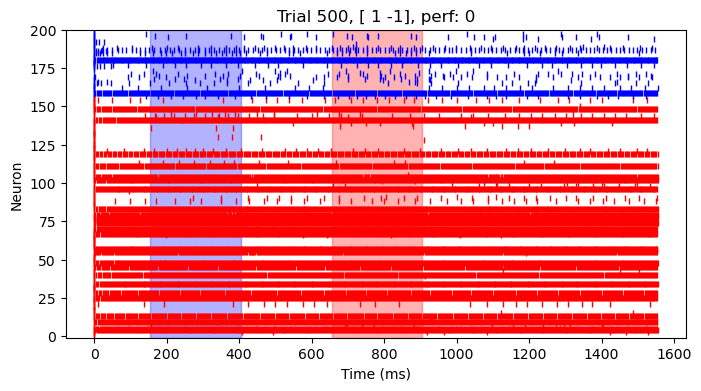

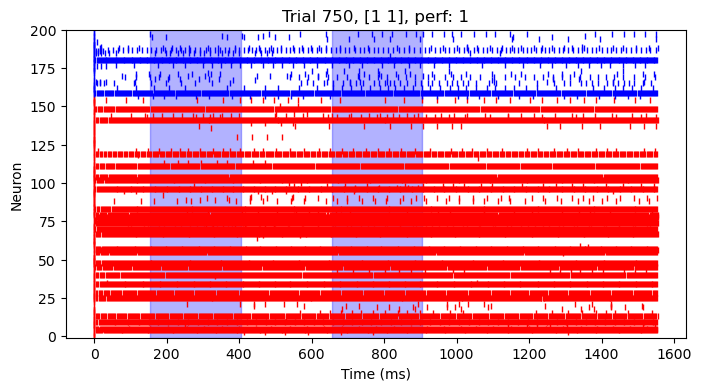

In [23]:
for trial_id in [0, 250, 500, 750]:
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]
    sn.plot_trial_raster(trial_df, 'delay', 50, all_models_dir=all_models_dir,)